In [1]:
%load_ext autoreload
%autoreload 2

import pygtfcode as gtf
from pprint import pprint

# Frank core-in-core example

In [34]:
config = gtf.Config()
config.init = ('truncated_NFW', {'Zt': 0.00807, 'deltaP': 1.0e-5, 'Mvir': 1.0e12, 'cvir': 30})

config.sim.sigma_m = 0.3
config.sim.c = 0.88
config.sim.t_halt = 1.0e6
config.sim.rho_c_halt = 1.0e12

config.prec.eps_dt = 1.0e-1
config.prec.eps_du = 1.0e-2

config.grid.rmin = 0.001
config.grid.rmax = 300
config.grid.ngrid = 500

config.io.nupdate = 3500
config.io.model_no = 104 # Testing

In [35]:
state = gtf.State.from_config(config)

Computing characteristic parameters for simulation...
Generating lookup for rho(phi)...
Computing potential profile for truncated NFW halo...
Integrating Poisson equation outward: r = 1172.656585, phi = -0.000000
Setting up radial grid...
Initializing profiles...
Computing Menc: r = 300.000, m = 4.528
Generating lookup for v2 integrand...


/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/pygtfcode/profiles/truncated_nfw.py:274: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(


Computing v2: r = 296.256, v2 = 0.003
Ensuring initial hydrostatic equilibrium...
	Initial pressure correction applied. HE residual improved 2.409e+01 -> 8.932e-14.
Hydrostatic equilibrium achieved in 4 iterations. Max |dr/r| = 1.71e-14.  HE res 1.0000719224907384.
State initialized.
Created directory: /Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model104
Model information written to model_metadata.txt
Initial profiles written to disk.


In [36]:
state.run()

Initial profiles written to disk.
Time evolution file initialized.
Log file initialized:
      step          time          <dt>         rho_c         v_max        Kn_min  <dt lim>  <du lim>  <dr lim>  <n_iter_du>  <n_iter_dr>
         0  0.000000e+00           N/A  1.404801e+03  3.069694e-01  1.282507e+01       N/A       N/A       N/A          N/A          N/A
    100000  3.870336e+02  3.870336e-03  5.960939e+07  1.165015e+00  2.305512e-03  6.29e+01  1.94e-02  5.64e-04  0.00000e+00  2.00114e+00
    200000  3.871574e+02  1.238591e-06  1.780938e+11  2.778517e+00  1.768557e-05  9.13e+05  6.65e-02  1.07e-03  0.00000e+00  2.00000e+00
Simulation halted: central density exceeds halting value
    232421  3.871976e+02  1.238591e-06  1.000008e+12  3.200834e+00  6.478755e-06  1.84e+07  8.79e-02  2.17e-03  0.00000e+00  2.00000e+00
Total time for run(): 22.43s


In [30]:
state.make_movie(profiles=['rho', 'v2', 'kn'])

Generating 328 frames...


Frames: 100%|██████████| 328/328 [02:20<00:00,  2.33frame/s]


Compiling into a movie using ffmpeg...
Deleting frames...
Movie saved to /Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model103/movie_rho_v2_kn.mp4


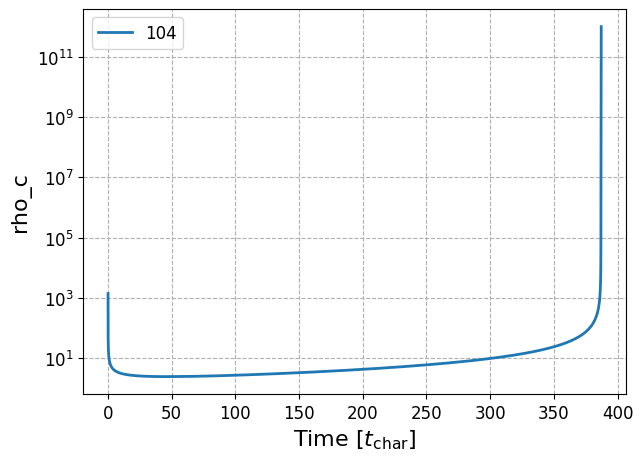

In [38]:
gtf.plot_time_evolution([104], base_dir='/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments', grid=True)

# Run all $\sigma_\mathrm{m}$ values in loop

In [2]:
sig_vals = [0.3, 1.0, 3.0, 5.0, 10.0, 20.0, 25.0, 50.0, 100.0, 200.0, 250.0]

In [ ]:
config = gtf.Config()
config.init = ('truncated_NFW', {'Zt': 0.00807, 'deltaP': 1.0e-5, 'Mvir': 1.0e12, 'cvir': 30})

config.sim.c = 0.88
config.sim.t_halt = 1.0e6
config.sim.rho_c_halt = 1.0e12

config.prec.eps_dt = 1.0e-1
config.prec.eps_du = 1.0e-2

config.grid.rmin = 0.001
config.grid.rmax = 300
config.grid.ngrid = 500

config.io.nupdate = 3500

In [ ]:
for ind, sig in enumerate(sig_vals):    
    config.sim.sigma_m = 0.3
    config.io.model_no = 104 # Testing